In [127]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob
from ase.io import read, write
from ase.build import make_supercell
import numpy as np

# FIGURA 1

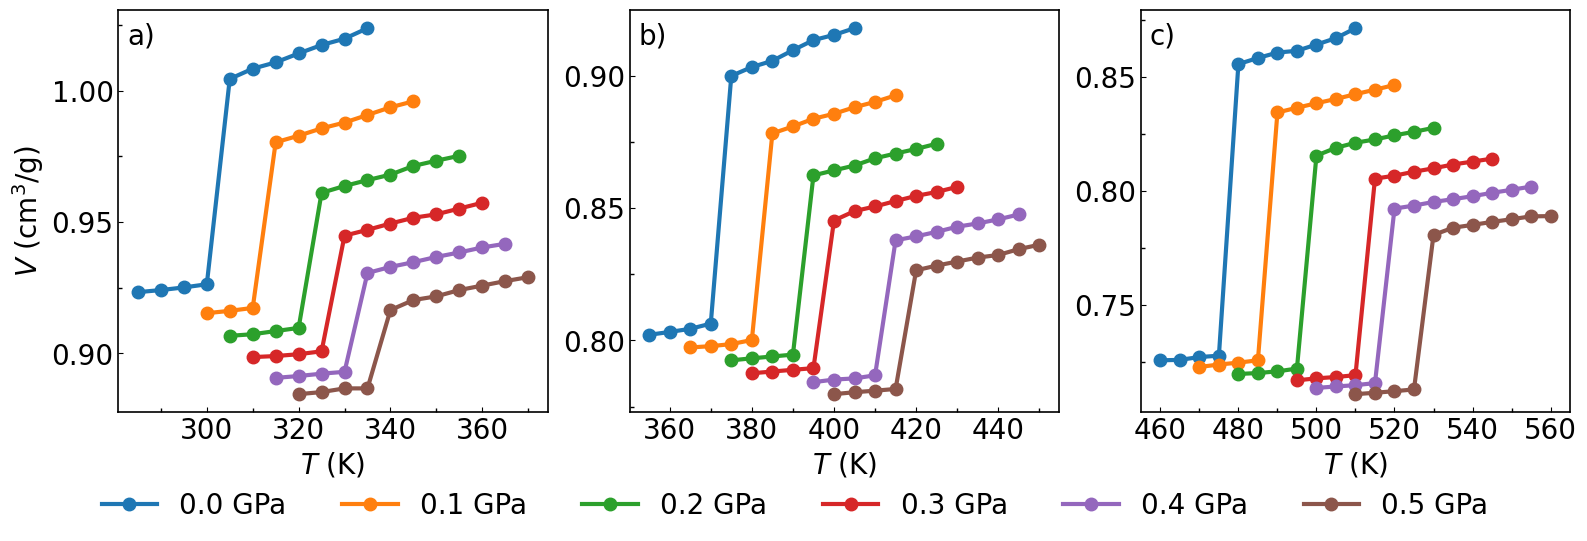

In [391]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob

colors_P  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
materials = ['NPG', 'PG', 'PE']
pressures = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vol_handles, vol_labels = [], []

for idx, (ax, material) in enumerate(zip(axes, materials)):
    files = sorted(glob.glob(f"/home/aressanuy/Desktop/doc/paper-npgpgpe/f_volum/P*_{material}.dat"))

    if not files:
        ax.text(0.5, 0.5, f'No data\n{material}',
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        continue

    for i, fpath in enumerate(files):
        try:
            data = np.loadtxt(fpath, comments='#')
            if data.ndim == 1:
                data = data[np.newaxis, :]
            T = data[:, 0]
            if   material == 'PE':  V = data[:, 1] * 0.0043
            elif material == 'NPG': V = data[:, 1]
            elif material == 'PG':  V = data[:, 1] * 0.0098

            line, = ax.plot(T, V, 'o-', color=colors_P[i % len(colors_P)],
                            linewidth=3, markersize=9)
            if idx == 0:
                vol_handles.append(line)
                vol_labels.append(f'{pressures[i]} GPa')
        except Exception as e:
            print(f"  Error: {fpath}: {e}")

    ax.set_xlabel(r'$T$ (K)', fontsize=20)
    if idx == 0:
        ax.set_ylabel(r'$V$ (cm$^3$/g)', fontsize=20)
    ax.text(0.02, 0.97, f'{chr(97+idx)})', transform=ax.transAxes,
        fontsize=20, va='top', ha='left')
    ax.tick_params(axis='both', labelsize=20, direction='in')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=3, width=1, direction='in')
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

fig.legend(vol_handles, vol_labels,
           loc='lower center', ncol=len(pressures),
           fontsize=20, bbox_to_anchor=(0.5, -0.10), frameon=False)

plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig1.png',
            dpi=150, bbox_inches='tight')
plt.show()


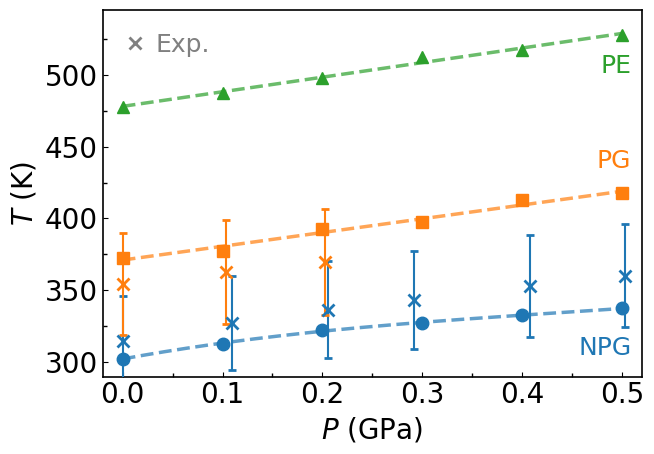

In [547]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

colors_M  = {'NPG': 'tab:blue', 'PG': 'tab:orange', 'PE': 'tab:green'}
markers_M = {'NPG': 'o',        'PG': 's',           'PE': '^'}
degrees   = {'NPG': 3,          'PG': 1,             'PE': 1}

P_sim  = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
data_T = {
    'NPG': [302.5, 312.5, 322.5, 327.5, 332.5, 337.5],
    'PG':  [372.5, 377.5, 392.5, 397.5, 412.5, 417.5],
    'PE':  [477.5, 487.5, 497.5, 512.5, 517.5, 527.5],
}

_npg_data = np.loadtxt('/home/aressanuy/Desktop/doc/paper-npgpgpe/fitxers/PT_NPG_exp.dat', comments='#')
_npg_P, _npg_T = _npg_data[:, 0], _npg_data[:, 1]
_pg_T = np.array([354.24, 362.71, 369.74])

exp_T = {
    'NPG': {'P': _npg_P,                          'T': _npg_T},
    'PG':  {'P': np.array([0, 1039, 2026])/10000, 'T': _pg_T},
    'PE':  None,
}

fig, ax = plt.subplots(figsize=(7, 5))
P_fit = np.linspace(0, 0.5, 300)

for mat, T_list in data_T.items():
    T = np.array(T_list)
    ax.plot(P_sim, T, markers_M[mat], color=colors_M[mat], markersize=9, zorder=5)
    coefs = np.polyfit(P_sim, T, degrees[mat])
    ax.plot(P_fit, np.poly1d(coefs)(P_fit),
            '--', color=colors_M[mat], linewidth=2.5, alpha=0.7)

for mat, edata in exp_T.items():
    if edata is None:
        continue
    T_exp = np.array(edata['T'])
    ax.errorbar(edata['P'], T_exp, yerr=0.1 * T_exp,
                fmt='x', color=colors_M[mat], ecolor=colors_M[mat],
                capsize=3, elinewidth=1.5, markersize=8, markeredgewidth=2,
                zorder=4)

ax.set_xlabel(r'$P$ (GPa)', fontsize=20)
ax.set_ylabel(r'$T$ (K)',   fontsize=20)
ax.set_ylim(290, 545)
ax.set_xlim(-0.02, 0.52)
ax.tick_params(axis='both', labelsize=20, direction='in')
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.tick_params(which='minor', length=3, width=1, direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# ── Llegendes individuals dins el gràfic ─────────────────────────────────────
# ── Llegenda ──────────────────────────────────────────────────────────────────
exp_h = Line2D([0],[0], marker='x', color='gray', linestyle='None',
               markersize=9, markeredgewidth=2)

leg_exp = ax.legend(handles=[exp_h], labels=['Exp.'],
          loc='upper left', bbox_to_anchor=(0.0, 1.0),
          fontsize=18, frameon=False, handlelength=0.8, handletextpad=0.4)
leg_exp.get_texts()[0].set_color('gray')


ax.text(0.98, 0.88, 'PE',  transform=ax.transAxes, fontsize=18,
        color=colors_M['PE'],  ha='right', va='top')
ax.text(0.98, 0.62, 'PG',  transform=ax.transAxes, fontsize=18,
        color=colors_M['PG'],  ha='right', va='top')
ax.text(0.98, 0.11, 'NPG', transform=ax.transAxes, fontsize=18,
        color=colors_M['NPG'], ha='right', va='top')


plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig2.png',
            dpi=600, bbox_inches='tight')
plt.show()



# FIGURA 4

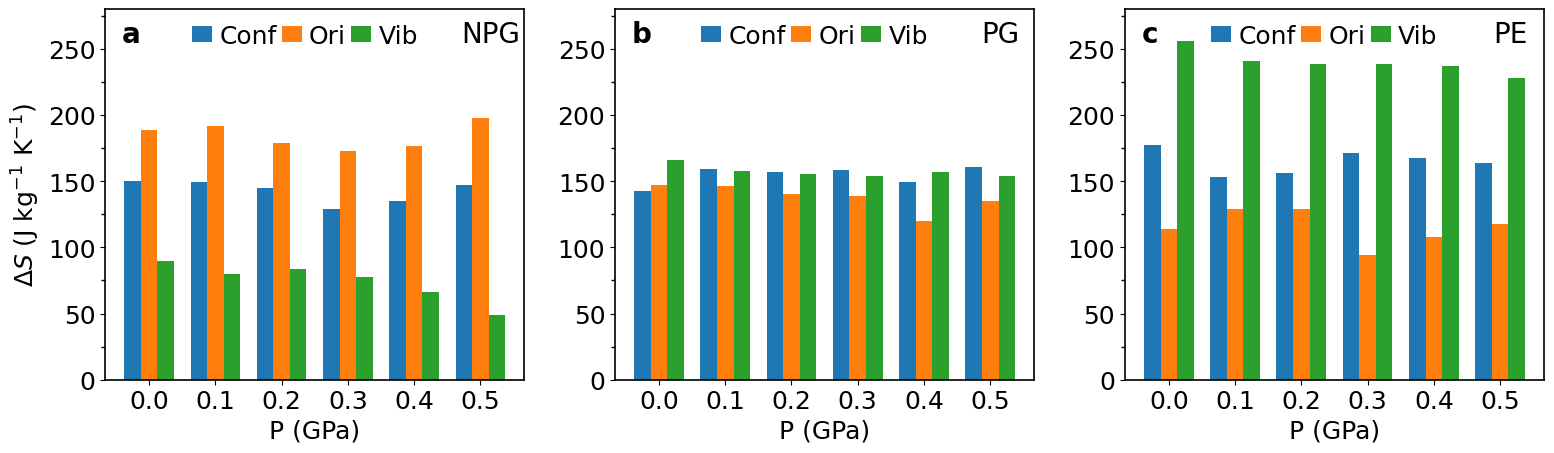

In [550]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pressures_labels = ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5']
x = np.arange(6)
width = 0.25

data = {
    'NPG': {
        'ori':  [188.37, 191.39, 179.09, 173.00, 176.70, 197.71],
        'conf': [150.45, 149.34, 144.81, 129.00, 134.76, 146.92],
        'vib':  [ 90.00,  80.00,  83.36,  77.82,  66.36,  48.77],
    },
    'PG': {
        'ori':  [147.26, 146.45, 140.38, 139.00, 119.90, 135.32],
        'conf': [142.25, 159.08, 156.75, 158.43, 149.12, 160.99],
        'vib':  [165.96, 157.92, 155.66, 153.67, 156.67, 153.75],
    },
    'PE': {
        'ori':  [113.91, 129.13, 129.27, 94.27, 107.88, 117.99],
        'conf': [177.26, 153.21, 156.04, 171.46, 167.45, 163.80],
        'vib':  [255.94, 240.93, 238.59, 238.15, 236.62, 227.64],
    },
}

hbonds = {'NPG': 2, 'PG': 3, 'PE': 4}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

legend_handles = None

for idx, (ax, (material, vals)) in enumerate(zip(axes, data.items())):
    ori  = vals['ori']
    conf = vals['conf']
    vib  = vals['vib']

    b1 = ax.bar(x - width, conf, width, color='#1f77b4', label=r'$\Delta S_{conf}$')
    b2 = ax.bar(x,         ori,  width, color='#ff7f0e', label=r'$\Delta S_{ori}$')
    b3 = ax.bar(x + width, vib,  width, color='#2ca02c', label=r'$\Delta S_{vib}$')

    ax.set_xlabel('P (GPa)', fontsize=18)#!/usr/bin/env python3



    if idx == 0:
        ax.set_ylabel(r'$\Delta S$ (J kg$^{-1}$ K$^{-1}$)', fontsize=18)
        legend_handles = [b1, b2, b3]

    ax.set_xticks(x)
    ax.set_xticklabels(pressures_labels, fontsize=18)
    ax.set_ylim(0, 280)
    ax.text(0.04, 0.97, f'{chr(97+idx)}', transform=ax.transAxes,
        fontsize=20, va='top', ha='left', fontweight='bold')

    ax.text(0.92, 0.97, f'{materials[idx]}', transform=ax.transAxes,
        fontsize=20, va='top', ha='center')
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(axis='both', labelsize=18)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=3, width=1)
    ax.legend(handles=legend_handles, labels=['Conf', 'Ori', 'Vib'], loc='upper right',
              fontsize=18, frameon=False, ncol=3, columnspacing=0.2, handletextpad=0.3,
              bbox_to_anchor=(0.80, 1.02), handlelength=0.8, handleheight=0.6)





    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Obté els límits dels eixos en coordenades de figura
ax = fig.get_axes()
left = min(a.get_position().x0 for a in ax)
right = max(a.get_position().x1 for a in ax)
center = (left + right) / 2


plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig4.png', dpi=300, bbox_inches='tight')
plt.show()

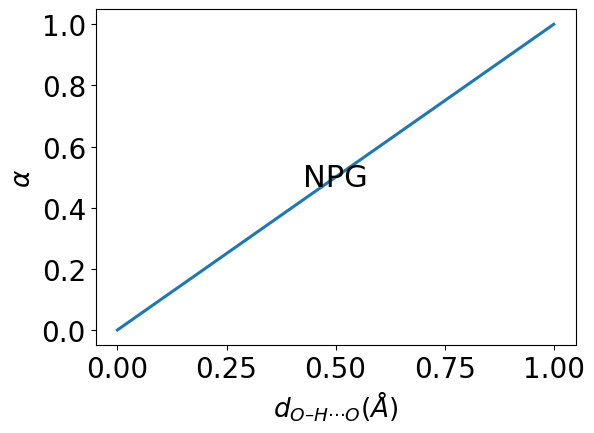

In [585]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fig, ax = plt.subplots()

# --- la teva figura aquí ---
ax.plot([0, 1], [0, 1])
ax.set_xlabel(r"$d_{O–H···O} (Å)$", fontsize=19,fontweight='bold')
ax.set_ylabel(r'$\alpha$ ', fontsize=19)
#ax.xaxis.label.set_color('blue')             # xlabel
#ax.yaxis.label.set_color('blue')  

# Agafa la font que matplotlib està usant per als eixos
axis_font = fm.FontProperties(
    family=plt.rcParams["font.family"],
    size=plt.rcParams["font.size"],      # mateixa mida que els tick labels
    style=plt.rcParams["font.style"],
    weight=plt.rcParams["font.weight"],
)

# Afegeix text amb la mateixa font
ax.text(
    0.5, 0.5,               # coordenades (en unitats de dades, o usa transform=ax.transAxes per fracció)
    "NPG",
    fontproperties=axis_font,
    ha="center", va="center",
    transform=ax.transAxes   # elimina aquesta línia si vols coordenades de dades
)

plt.tight_layout()
plt.savefig("/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/figura_text.pdf", dpi=300)
plt.show()

In [294]:
import numpy as np

x = np.linspace(0, 4*np.pi, 200)
y = np.sin(x)

# Genera path SVG
points = " ".join(f"{xi*50:.2f},{-yi*30+50:.2f}" for xi, yi in zip(x, y))
svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="640" height="100">
  <polyline points="{points}" fill="none" stroke="blue" stroke-width="1.5"/>
</svg>'''

with open("/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/sinus.svg", "w") as f:
    f.write(svg)

Figura guardada.


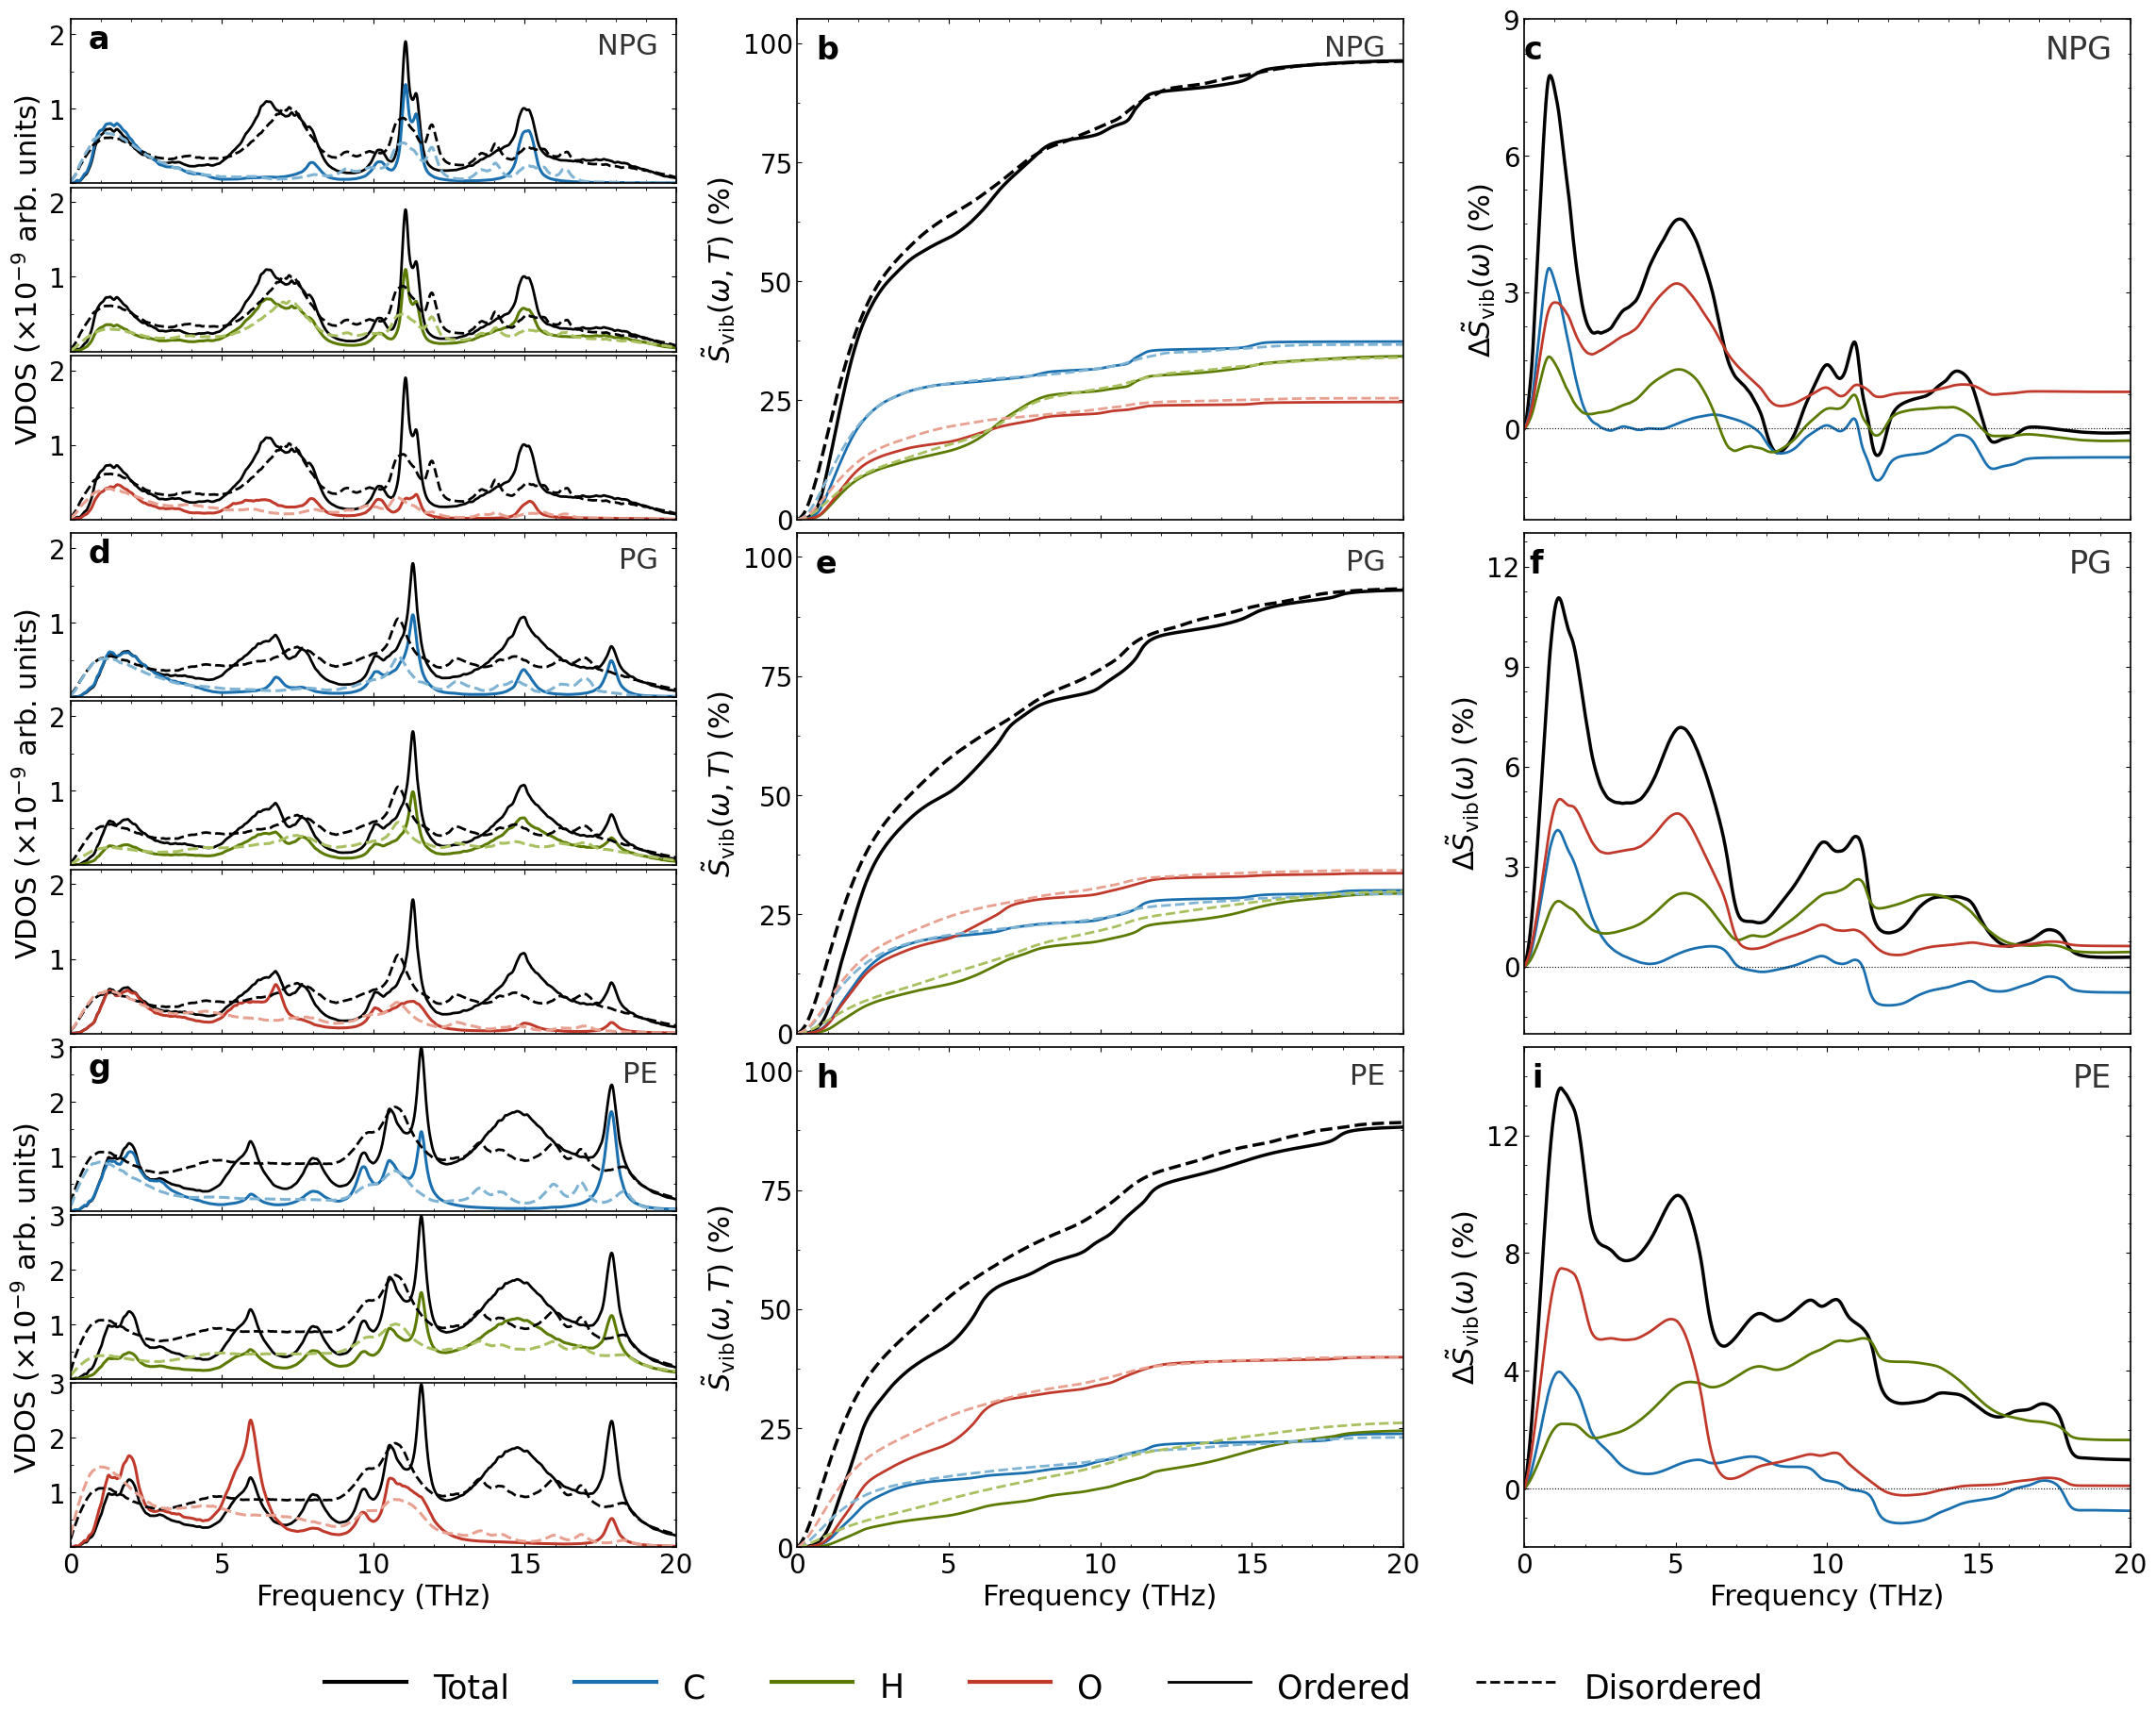

In [557]:
import sys
import os
BASE_DIR = "/home/aressanuy/Desktop/doc/paper-npgpgpe/fitxers/figurapdos"
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

nsteps = 40000
metode = 'pydos'

# -------------------------
# Mides de lletra i línies (font per defecte de matplotlib, sense canviar família)
# -------------------------
plt.rcParams.update({
    'font.size':        22,
    'axes.labelsize':   22,
    'axes.titlesize':   22,
    'xtick.labelsize':  20,
    'ytick.labelsize':  20,
    'legend.fontsize':  22,
    'lines.linewidth':  2.2,
})

ELEMS  = ["C", "H", "O"]
SISTEMES = {
    'NPG': {'temps': [300, 305]},
    'PG':  {'temps': [370, 375]},
    'PE':  {'temps': [475, 480]},
}
COLORS = {
    0: {"Total": "#000000", "C": "#1a6faf", "H": "#5a7a00", "O": "#c0392b"},
    1: {"Total": "#000000", "C": "#7fb3d3", "H": "#a8c060", "O": "#e8a090"},
}
LS        = {0: '-', 1: '--'}
sigma     = 3
YLIM_PDOS = {'NPG': 2.2e-9, 'PG': 2.2e-9, 'PE': 3.0e-9}

# Labels de subfigura: columna PDOS → (a)(d)(g), Svib → (b)(e)(h), ΔSvib → (c)(f)(i)
PANEL_LABELS = {
    'NPG': {'pdos': 'a', 'svib': 'b', 'dsvib': 'c'},
    'PG':  {'pdos': 'd', 'svib': 'e', 'dsvib': 'f'},
    'PE':  {'pdos': 'g', 'svib': 'h', 'dsvib': 'i'},
}

n_sis  = len(SISTEMES)
# 3 files de dades per material + 1 fila de separació entre materials
# height_ratios: files de dades = 3, files separació = 0.4
n_rows = n_sis * 3 + (n_sis - 1)  # ajusta els valors

hr = []
for i in range(n_sis):
    hr += [3, 3, 3]
    if i < n_sis - 1:
        hr += [0.1]   # separació mínima entre materials

fig = plt.figure(figsize=(24, 20))
gs  = GridSpec(n_rows, 3, figure=fig, hspace=0.03, height_ratios=hr)
row_offset = {'NPG': 0, 'PG': 4, 'PE': 8}

for nom, cfg in SISTEMES.items():
    temps  = cfg['temps']
    T0, T1 = temps
    CT     = {T0: COLORS[0], T1: COLORS[1]}
    LST    = {T0: LS[0],     T1: LS[1]}
    ro     = row_offset[nom]
    plbl   = PANEL_LABELS[nom]

    # carregar pdos
    pdos_data = {}
    for T in temps:
        if metode == 'vacf':
            # vacf
            freq, pdos_tot = np.loadtxt(os.path.join(BASE_DIR, f"pdos_vacf_total_{nom}_{T}_nsteps{nsteps}.dat"), unpack=True)
            pdos_sp = {e: np.loadtxt(os.path.join(BASE_DIR, f"pdos_vacf_{e}_{nom}_{T}_nsteps{nsteps}.dat"), unpack=True)[1] for e in ELEMS}

        else:
            freq, pdos_tot = np.loadtxt(os.path.join(BASE_DIR, f"pdos_pydos_{nom}_T_{T}.dat"), unpack=True)
            pdos_sp = {e: np.loadtxt(os.path.join(BASE_DIR, f"pdos_pydos_{nom}_T_{T}_pdos_{e}.dat"), unpack=True)[1] for e in ELEMS}
        pdos_data[T] = {'freq': freq, 'pdos_tot': pdos_tot, 'pdos_sp': pdos_sp}

    # carregar svib precalculats
    svib = {}
    for T in temps:
        d = np.loadtxt(os.path.join(BASE_DIR, f"svib_acum_{nom}_{T}_{metode}.dat"), unpack=True)
        svib[T] = {'freq': d[0], 'C': d[1], 'H': d[2], 'O': d[3], 'Suma': d[4]}

    ax_C = fig.add_subplot(gs[ro+0, 0])
    ax_H = fig.add_subplot(gs[ro+1, 0])
    ax_O = fig.add_subplot(gs[ro+2, 0])
    ax2  = fig.add_subplot(gs[ro:ro+3, 1])
    ax3  = fig.add_subplot(gs[ro:ro+3, 2])

    # -------------------------
    # COLUMNA 1: PDOS per element
    # -------------------------
    for i_ax, (ax, e) in enumerate(zip([ax_C, ax_H, ax_O], ELEMS)):
        for T in temps:
            freq_THz   = pdos_data[T]['freq'] * 1e-12
            pdos_tot_s = gaussian_filter1d(pdos_data[T]['pdos_tot'],   sigma=sigma)
            pdos_sp_s  = gaussian_filter1d(pdos_data[T]['pdos_sp'][e], sigma=sigma)
            ax.plot(freq_THz, pdos_tot_s, color=CT[T]["Total"], lw=2.0, ls=LST[T])
            ax.plot(freq_THz, pdos_sp_s,  color=CT[T][e],       lw=2.2, ls=LST[T])

        ax.set_xlim(0, 20)
        ax.set_ylim(0, YLIM_PDOS[nom])
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1e-9))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5e-9))
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda v, _: '' if v == 0 else f'{v*1e9:.0f}'))
        ax.tick_params(which="both", direction="in", top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

        if e == 'H':
            ax.set_ylabel(r"VDOS ($\times 10^{-9}$ arb. units)", fontsize=22)
        else:
            ax.set_ylabel("")


    # Label sistema (NPG/PG/PE) dins ax_C, dalt-dreta
    ax_C.text(0.97, 0.92, nom, transform=ax_C.transAxes,
              fontsize=22, va='top', ha='right', color='#333333')

    # Label de panel (a)/(d)/(g) a ax_C
    ax_C.text(0.03, 0.97, plbl['pdos'], transform=ax_C.transAxes,
              fontsize=24, va='top', ha='left',fontweight='bold')

    is_last = (nom == 'PE')

    ax_C.xaxis.set_ticklabels([])
    ax_H.xaxis.set_ticklabels([])
    if is_last:
        ax_O.set_xlabel("Frequency (THz)")
    else:
        ax_O.xaxis.set_ticklabels([])
        ax_O.set_xlabel("")

    # -------------------------
    # COLUMNA 2: Svib acumulativa
    # -------------------------
    ax = ax2
    freq_THz = svib[T0]['freq'] * 1e-12
    for T in temps:
        ax.plot(freq_THz, svib[T]['Suma'], color=CT[T]["Total"], lw=2.5, ls=LST[T])
        for e in ELEMS:
            ax.plot(freq_THz, svib[T][e], color=CT[T][e], lw=2.0, ls=LST[T])

    if is_last:
        ax.set_xlabel("Frequency (THz)")
    else:
        ax.xaxis.set_ticklabels([])
        ax.set_xlabel("")
    # Eix y: sols a PG
    ax.set_ylabel(r"$\tilde{S}_{\rm vib}(\omega, T)$ (%)", fontsize=22)
    ax.set_xlim(0, 20)
    ax.set_ylim(bottom=0)
    # Més tics x
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(12.5))
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, pos: '' if pos == 0 else f'{v:.0f}'))

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    # Label de panel (b)/(e)/(h)
    ax.text(0.03, 0.97, plbl['svib'], transform=ax.transAxes,
            fontsize=24, va='top', ha='left',fontweight='bold')
    # Nom sistema baix-dreta, allunyat de les línies
    ax.text(0.97, 0.97, nom, transform=ax.transAxes,
            fontsize=22, va='top', ha='right', color='#333333')

    # -------------------------
    # COLUMNA 3: ΔSvib = resta directa de les dues corbes de Svib acum (columna 2)
    # -------------------------
    ax = ax3
    freq_THz = svib[T0]['freq'] * 1e-12
    dsvib = {k: svib[T1][k] - svib[T0][k] for k in ['C', 'H', 'O', 'Suma']}

    ax.plot(freq_THz, dsvib['Suma'], color=COLORS[0]["Total"], lw=2.5)
    for e in ELEMS:
        ax.plot(freq_THz, dsvib[e], color=COLORS[0][e], lw=2.0)
    ax.axhline(0, color='k', lw=0.8, ls=':')

    # Àrea sota la corba (integral en freqüència, unitats: % · THz)
    area_suma = simpson(dsvib['Suma'], freq_THz)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    if is_last:
        ax.set_xlabel("Frequency (THz)")
    else:
        ax.xaxis.set_ticklabels([])
        ax.set_xlabel("")
    # Eix y: sols a PG
    
    ax.set_ylabel(r"$\Delta \tilde{S}_{\rm vib}(\omega)$ (%)", fontsize=22)
    
    ax.set_xlim(0, 20)
    ylims_dsvib = {
    'NPG': (-2, 9),
    'PG':  (-2, 13),
    'PE':  (-2, 15),
}
    yticks_dsvib = {
    'NPG': 3,
    'PG':  3.0,
    'PE':  4,
}


    ax3.set_ylim(ylims_dsvib[nom])
    ax3.yaxis.set_major_locator(ticker.MultipleLocator(yticks_dsvib[nom]))

    # Més tics x
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)

    ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, pos: '' if pos == 0 else f'{v:.0f}')
)


    # Label de panel (c)/(f)/(i) - dreta
    ax.text(0.03, 0.97, plbl['dsvib'], transform=ax.transAxes,
            fontsize=24, va='top', ha='right', fontweight='bold')
    ax.text(0.97, 0.97, nom, transform=ax.transAxes,
            fontsize=24, va='top', ha='right', color='#333333')

custom_global = [
    Line2D([0], [0], color=COLORS[0]["Total"], lw=3, ls='-',  label='Total'),
    Line2D([0], [0], color=COLORS[0]["C"],     lw=3, ls='-',  label='C'),
    Line2D([0], [0], color=COLORS[0]["H"],     lw=3, ls='-',  label='H'),
    Line2D([0], [0], color=COLORS[0]["O"],     lw=3, ls='-',  label='O'),
    Line2D([0], [0], color='k',                lw=2, ls='-',  label=r'Ordered'),
    Line2D([0], [0], color='k',                lw=2, ls='--', label=r'Disordered'),
]

fig.legend(handles=custom_global, loc='lower center', ncol=6,
           frameon=False, fontsize=25, bbox_to_anchor=(0.5, 0.06),
           bbox_transform=fig.transFigure, handlelength=2.5, handleheight=1.5)

plt.subplots_adjust(left=0.07, right=0.98, top=0.97, bottom=0.16, hspace=0.4, wspace=0.2)
plt.savefig(f"/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/svib_NPG_PG_PE_{metode}.png", dpi=200, bbox_inches='tight')
#plt.show()
print("Figura guardada.")

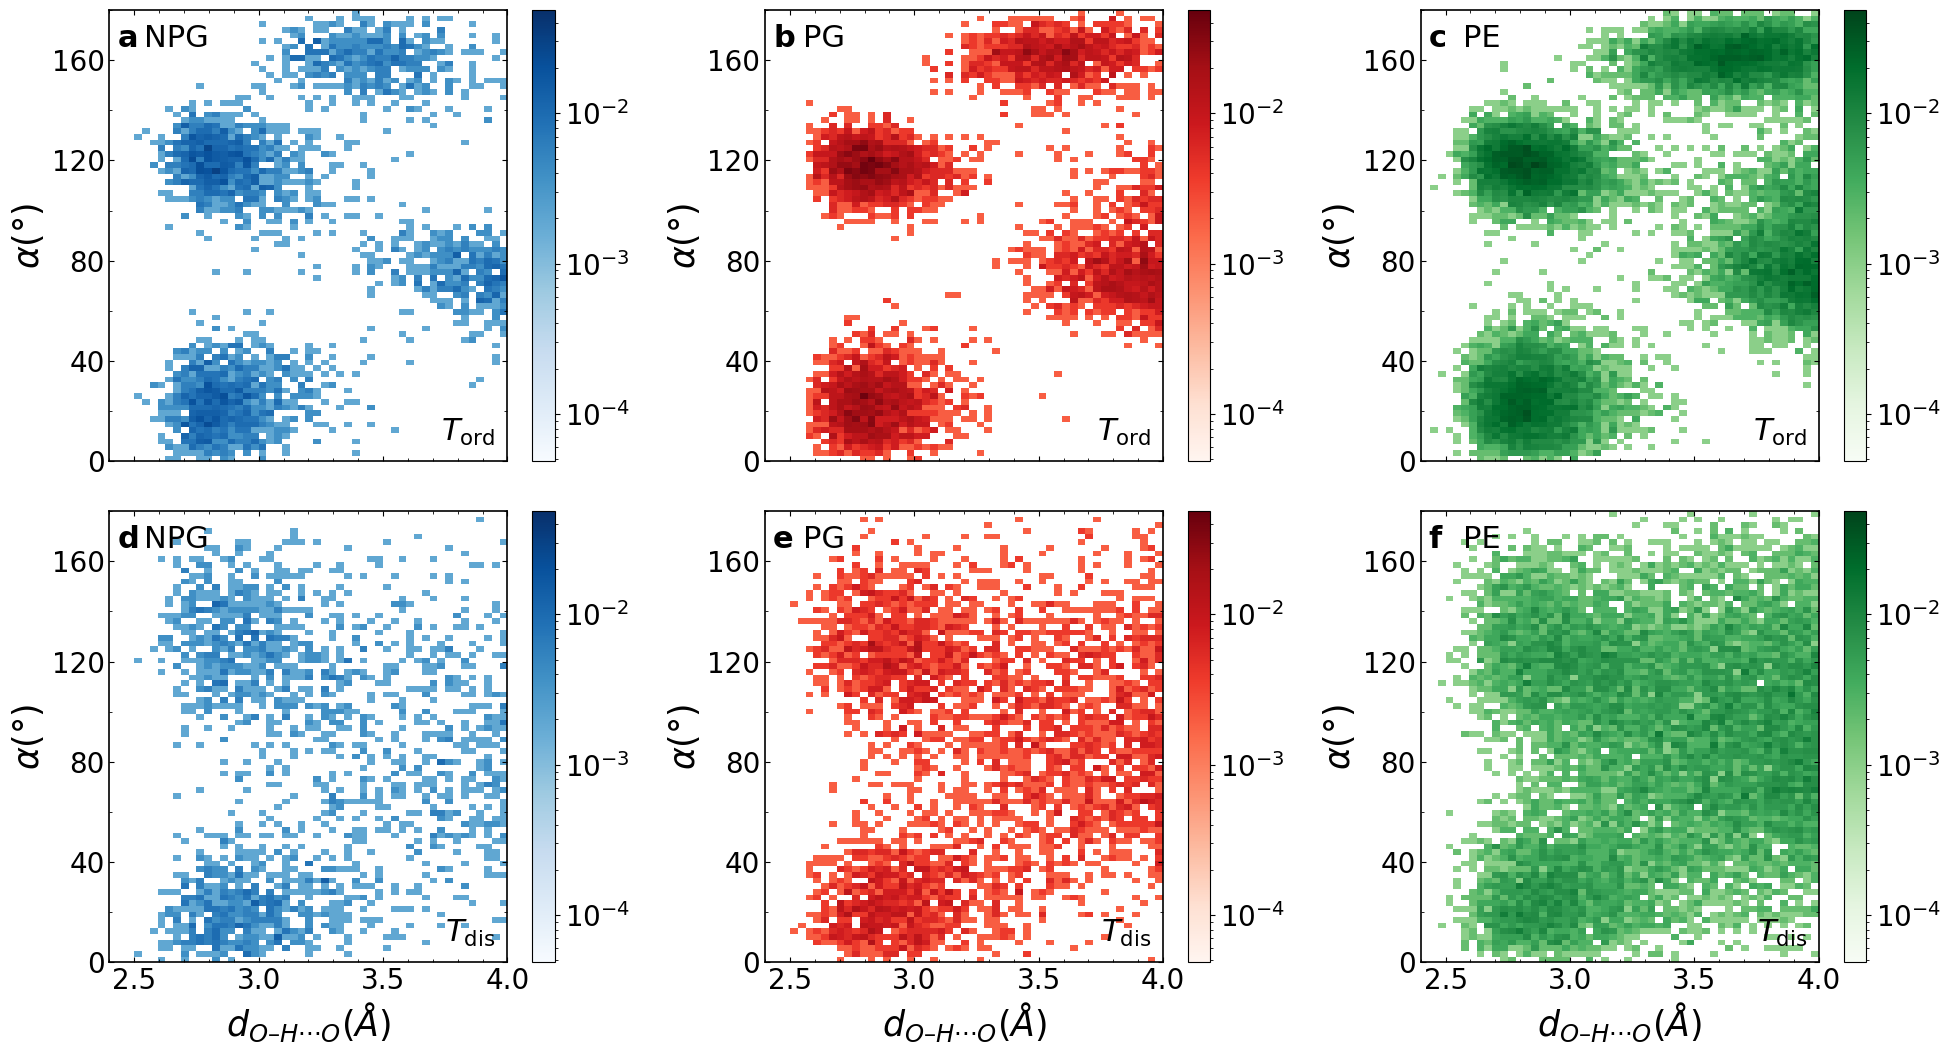

In [ ]:

import sys
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

# ============================================================
COMPOUNDS = {
    "NPG": {"resname": "LIG",  "oxygens": "O1 O2",          "hydrogens": "H1 H2",          "n_oh": 2, "color": "Blues"},
    "PG":  {"resname": "RES1", "oxygens": "O O1 O2",         "hydrogens": "H9 H10 H11",     "n_oh": 3, "color": "Reds"},
    "PE":  {"resname": "RES1", "oxygens": "O1 O1B O1D O1F",  "hydrogens": "H3 H3B H3D H3F", "n_oh": 4, "color": "Greens"},
}
P    = 1
BINS = 80
# ============================================================

def get_dist_angles(tpr, trr, cfg):
    u         = mda.Universe(tpr, trr)
    donor_sel = f"resname {cfg['resname']} and name {cfg['oxygens']}"
    hydro_sel = f"resname {cfg['resname']} and name {cfg['hydrogens']}"
    n_mol     = len(u.select_atoms(donor_sel)) // cfg["n_oh"]

    hbonds = HydrogenBondAnalysis(
        universe=u,
        donors_sel=donor_sel,
        hydrogens_sel=hydro_sel,
        acceptors_sel=donor_sel,
        d_a_cutoff=4.0,
        d_h_a_angle_cutoff=0,
        update_selections=False,
    )
    hbonds.run(stop=1)
    n_frames = hbonds.n_frames

    # Exclou intramoleculars
    oxygens     = u.select_atoms(donor_sel)
    atom_to_mol = {atom.index: i // cfg["n_oh"] for i, atom in enumerate(oxygens)}
    mask_inter  = np.array([
        atom_to_mol.get(int(hb[1]), -1) != atom_to_mol.get(int(hb[3]), -2)
        for hb in hbonds.results.hbonds
    ])
    hb_inter = hbonds.results.hbonds[mask_inter]

    dist   = hb_inter[:, 4]
    angles = 180 - hb_inter[:, 5]
    return dist, angles, n_mol, n_frames

T_vals = {
    "NPG": (250, 340),
    "PG":  (310, 375),
    "PE":  (400, 480),
}

# Primer pas: calcula tots els histogrames normalitzats
hists = {}
for compound, cfg in COMPOUNDS.items():
    hists[compound] = {}
    for label, T in [("Ordenada", T_vals[compound][0]),
                     ("Desordenada", T_vals[compound][1])]:
        tpr = f"/home/aressanuy/Desktop/doc/paper-npgpgpe/pontsh/run_{T}_{P}.tpr"
        trr = f"/home/aressanuy/Desktop/doc/paper-npgpgpe/pontsh/run_{T}_{P}.trr"
        try:
            dist, angles, n_mol, n_frames = get_dist_angles(tpr, trr, cfg)
            # Histograma 2D normalitzat per n_mol × n_frames
            H, xedges, yedges = np.histogram2d(
                dist, angles,
                bins=BINS,
                range=[[1.5, 4.0], [0, 180]]
            )
            H = H / (n_mol * n_frames)  # normalitza
            hists[compound][label] = {
                "H": H, "xedges": xedges, "yedges": yedges,
                "T": T, "n_mol": n_mol, "n_frames": n_frames
            }
        except Exception as e:
            print(f"    [ERROR] {e}")
            hists[compound][label] = None

# Rang global per la colorbar (mateix per tots els panells)
all_vals = [hists[c][l]["H"].max()
            for c in hists for l in hists[c]
            if hists[c][l] is not None]
vmax = np.percentile(all_vals, 95)  # usa percentil 95 per evitar outliers
vmin = vmax * 1e-3

# Figura
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for col, (compound, cfg) in enumerate(COMPOUNDS.items()):
    for row, label in enumerate(["Ordenada", "Desordenada"]):
        
        ax   = axes[row][col]
        data = hists[compound].get(label)

        if data is None:
            ax.set_title(f"{compound} {label} — ERROR")
            continue

        H       = data["H"].T  # transposem per tenir dist a X i angle a Y
        xedges  = data["xedges"]
        yedges  = data["yedges"]
        T       = data["T"]

        im = ax.pcolormesh(xedges, yedges, H,
                           cmap=cfg["color"],
                           norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))
        plt.colorbar(im, ax=ax)
        label_idx = row * len(COMPOUNDS) + col
        ax.text(0.02, 0.97, f'{chr(97 + label_idx)}',fontweight='bold',
                transform=ax.transAxes, fontsize=22,
                va='top', ha='left')
        


        #ax.axhline(90,  color="black", linestyle="--",  linewidth=2.2, label="90°")
        #ax.axhline(150, color="black",  linestyle="--", linewidth=2.2, label="150°")
        #ax.axvline(3.3, color="black", linestyle="--", linewidth=2.2, label="3.3 Å")
        ax.set_ylabel(r"$\alpha (°)$", fontsize=25)
        ax.set_xlabel(r"$d_{O–H···O} (Å)$", fontsize=25)
        if row == 0:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
        ax.tick_params(which="both", direction="in", top=True, right=True)
        ax.tick_params(axis='both', labelsize=20)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
        # Nom del compost a dalt a la dreta (sols primera fila)
        if row == 0 or row == 1:
            if col == 0:
                ax.text(0.25, 0.97, compound, transform=ax.transAxes,
                        fontsize=22, va='top', ha='right')
                
        if row == 0 or row == 1:
            if col == 1 or col == 2:
                ax.text(0.20, 0.97, compound, transform=ax.transAxes,
                        fontsize=22, va='top', ha='right')

        row_label = r'$T_{\rm ord}$' if row == 0 else r'$T_{\rm dis}$'
        ax.text(0.97, 0.03, row_label, transform=ax.transAxes,
                fontsize=22, fontweight='bold', va='bottom', ha='right')



        #ax.legend( fontsize=20, loc="upper left")
        ax.set_xlim(2.4, 4.0)
        ax.set_ylim(0, 180)

plt.tight_layout()
plt.savefig("/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/mapa2d_all.png",bbox_inches='tight', dpi=150)
plt.show()

